In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [105]:
df_all=pd.read_csv("v_order_fact_cleaned.csv", index_col=0)
df_all.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0000,0,58.9000,13.2900,72.1900,1.0000,72.1900,1.0000,2.0000,0.0000,5.0000,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff\r,cool_stuff\r,1.0000,Single,cool_stuff\r,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0000,0,239.9000,19.9300,259.8300,1.0000,259.8300,1.0000,3.0000,0.0000,4.0000,NaN,NaN,2017-05-13 00:00:00,pet_shop\r,pet_shop\r,1.0000,Single,pet_shop\r,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.0000,0,199.0000,17.8700,216.8700,1.0000,216.8700,1.0000,5.0000,0.0000,5.0000,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor\r,furniture_decor\r,1.0000,Single,furniture_decor\r,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0000,0,12.9900,12.7900,25.7800,1.0000,25.7800,1.0000,2.0000,0.0000,4.0000,NaN,NaN,2018-08-15 00:00:00,perfumery\r,perfumery\r,1.0000,Single,perfumery\r,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0000,0,199.9000,18.1400,218.0400,1.0000,218.0400,1.0000,3.0000,0.0000,5.0000,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools\r,garden_tools\r,1.0000,Single,garden_tools\r,varzea paulista,SP


This dataset includes all orders regardless of status (delivered, canceled, shipped, etc.), allowing us to analyze platform-level operational dynamics.

In [107]:
df=pd.read_csv("v_order_fact_delivered_cleaned.csv", index_col=0)
df.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state,has_review,gap_ratio,payment_ratio,discount_intensity,log_revenue,days_to_deliver_capped,log_price,log_freight,log_payment
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0000,0,58.9000,13.2900,72.1900,1,72.1900,1.0000,2.0000,0.0000,5.0000,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff,cool_stuff,1,Single,cool_stuff,campos dos goytacazes,RJ,1,0.0000,1.0000,0.0000,4.2931,7.0000,4.0927,2.6596,4.2931
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0000,0,239.9000,19.9300,259.8300,1,259.8300,1.0000,3.0000,0.0000,4.0000,NaN,NaN,2017-05-13 00:00:00,pet_shop,pet_shop,1,Single,pet_shop,santa fe do sul,SP,1,0.0000,1.0000,0.0000,5.5639,16.0000,5.4844,3.0412,5.5639
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.0000,0,199.0000,17.8700,216.8700,1,216.8700,1.0000,5.0000,0.0000,5.0000,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor,furniture_decor,1,Single,furniture_decor,para de minas,MG,1,0.0000,1.0000,0.0000,5.3839,8.0000,5.2983,2.9376,5.3839
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0000,0,12.9900,12.7900,25.7800,1,25.7800,1.0000,2.0000,0.0000,4.0000,NaN,NaN,2018-08-15 00:00:00,perfumery,perfumery,1,Single,perfumery,atibaia,SP,1,0.0000,1.0000,0.0000,3.2877,6.0000,2.6383,2.6239,3.2877
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0000,0,199.9000,18.1400,218.0400,1,218.0400,1.0000,3.0000,0.0000,5.0000,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools,garden_tools,1,Single,garden_tools,varzea paulista,SP,1,0.0000,1.0000,0.0000,5.3893,25.0000,5.3028,2.9518,5.3893


## 1. Order Lifecycle & Operational Overview

In [109]:
df_all.shape

(99441, 30)

### 1.1. Order Status Distribution

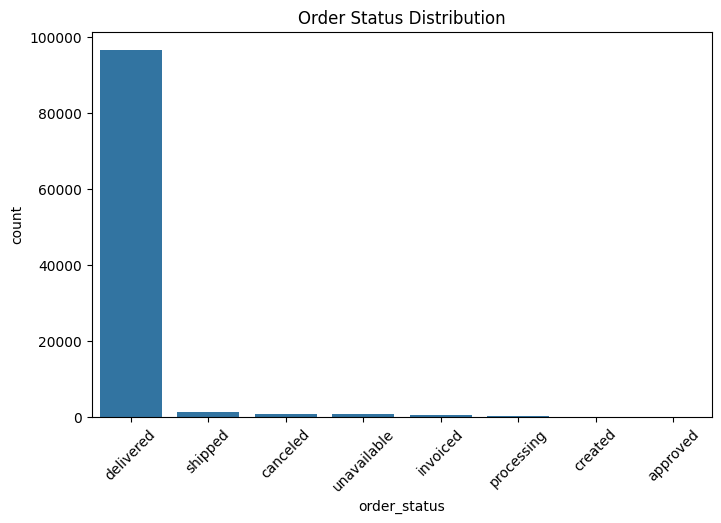

In [111]:
plt.figure(figsize=(8,5))
sns.countplot(data = df_all, x="order_status", order=df_all["order_status"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Order Status Distribution")
plt.show()

In [112]:
df_all["order_status"].value_counts(normalize=True)

order_status
delivered     0.9702
shipped       0.0111
canceled      0.0063
unavailable   0.0061
invoiced      0.0032
processing    0.0030
created       0.0001
approved      0.0000
Name: proportion, dtype: float64

The majority of orders are successfully delivered, indicating operational stability.
Cancellations and unavailable orders represent a small fraction of total activity.

### 1.2. Cancel Rate Analysis

In [115]:
cancel_rate = (df_all["order_status"] == "canceled").mean()
cancel_rate

0.006285133898492574

Overall cancellation rate: 0.006%
This is relatively low and suggests a stable transaction flow.

### 1.3. Payment Coverage by Status

In [118]:
pd.crosstab(
    df_all["order_status"],
    df_all["total_payment"].notnull(),
    normalize="index"
)

total_payment,False,True
order_status,,
approved,0.0000,1.0000
canceled,0.0000,1.0000
created,0.0000,1.0000
delivered,0.0000,1.0000
invoiced,0.0000,1.0000
processing,0.0000,1.0000
shipped,0.0000,1.0000
unavailable,0.0000,1.0000


Payment coverage is consistent across most statuses.

### 1.4. Revenue Availability by Status

In [121]:
df_all.groupby("order_status")["total_revenue"].apply(lambda x: x.isnull().mean())

order_status
approved      0.0000
canceled      0.2624
created       1.0000
delivered     0.0000
invoiced      0.0064
processing    0.0000
shipped       0.0009
unavailable   0.9901
Name: total_revenue, dtype: float64

Revenue is primarily missing in non-delivered statuses (canceled/unavailable), which is expected.

### 1.5. Order Volume Over Time

C:\Users\okand\AppData\Local\Temp\ipykernel_21780\375439363.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["order_id"]


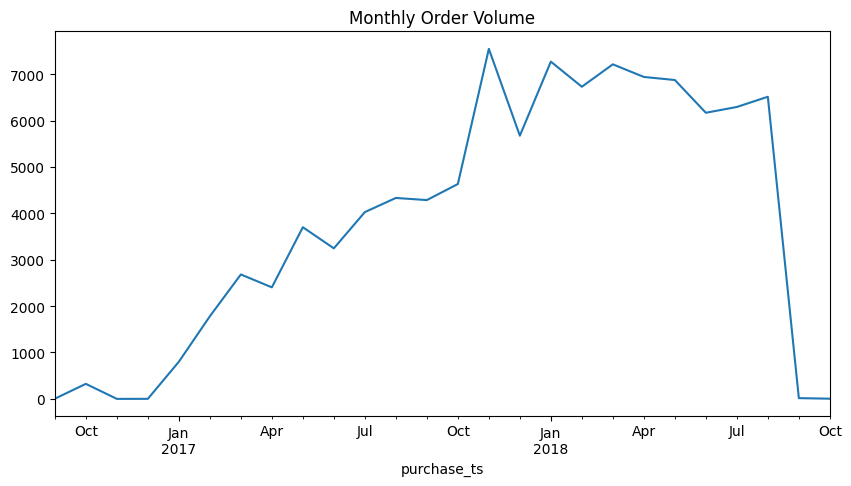

In [124]:
df_all["purchase_ts"] = pd.to_datetime(df_all["purchase_ts"], errors="coerce")

orders_monthly = (
    df_all
    .set_index("purchase_ts")
    .resample("M")["order_id"]
    .count()
)

orders_monthly.plot(figsize=(10,5), title="Monthly Order Volume")
plt.show()

Orders showed an upward trend until August 2018, but a sharp decline was observed starting in September 2018.

### 1.6. Revenue Over Time

C:\Users\okand\AppData\Local\Temp\ipykernel_21780\33757746.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["total_revenue"]


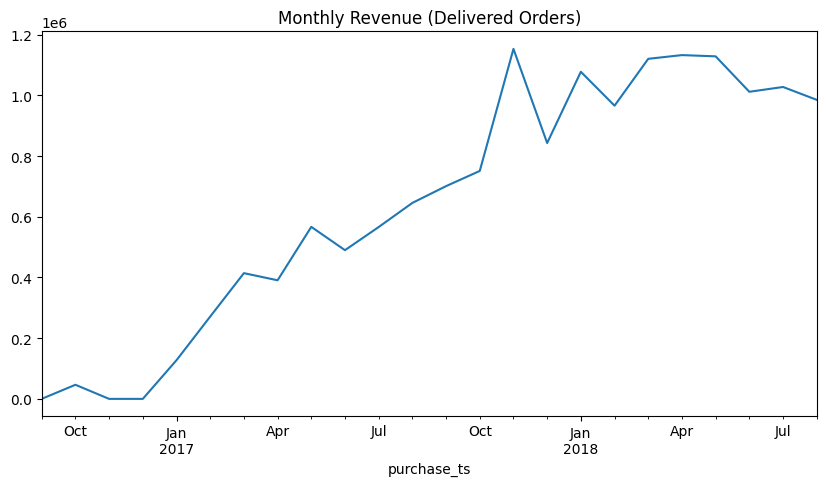

In [127]:
revenue_monthly = (
    df_all[df_all["order_status"] == "delivered"]
    .set_index("purchase_ts")
    .resample("M")["total_revenue"]
    .sum()
)

revenue_monthly.plot(figsize=(10,5), title="Monthly Revenue (Delivered Orders)")
plt.show()

- Monthly revenue shows a strong upward trend during 2017, indicating rapid platform growth.
- A noticeable spike occurs around late 2017, likely driven by seasonal events (e.g., Black Friday).
- In 2018, revenue stabilizes around a higher baseline, suggesting platform maturation and consistent demand.
- Overall trend confirms increasing customer adoption and transaction volume over time.

## 2. Revenue & Order Value Analysis

In [130]:
df.head()

,order_id,customer_id,customer_unique_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,est_delivery_ts,days_to_deliver,is_late,total_price,total_freight,total_revenue,item_count,total_payment,payment_count,max_installments,payment_minus_revenue,review_score,review_comment_title,review_comment_message,review_creation_date,main_category_by_item,main_category_by_revenue,category_count,order_type,all_categories,customer_city,customer_state,has_review,gap_ratio,payment_ratio,discount_intensity,log_revenue,days_to_deliver_capped,log_price,log_freight,log_payment
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0000,0,58.9000,13.2900,72.1900,1,72.1900,1.0000,2.0000,0.0000,5.0000,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,cool_stuff,cool_stuff,1,Single,cool_stuff,campos dos goytacazes,RJ,1,0.0000,1.0000,0.0000,4.2931,7.0000,4.0927,2.6596,4.2931
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0000,0,239.9000,19.9300,259.8300,1,259.8300,1.0000,3.0000,0.0000,4.0000,NaN,NaN,2017-05-13 00:00:00,pet_shop,pet_shop,1,Single,pet_shop,santa fe do sul,SP,1,0.0000,1.0000,0.0000,5.5639,16.0000,5.4844,3.0412,5.5639
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,8.0000,0,199.0000,17.8700,216.8700,1,216.8700,1.0000,5.0000,0.0000,5.0000,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,furniture_decor,furniture_decor,1,Single,furniture_decor,para de minas,MG,1,0.0000,1.0000,0.0000,5.3839,8.0000,5.2983,2.9376,5.3839
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0000,0,12.9900,12.7900,25.7800,1,25.7800,1.0000,2.0000,0.0000,4.0000,NaN,NaN,2018-08-15 00:00:00,perfumery,perfumery,1,Single,perfumery,atibaia,SP,1,0.0000,1.0000,0.0000,3.2877,6.0000,2.6383,2.6239,3.2877
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0000,0,199.9000,18.1400,218.0400,1,218.0400,1.0000,3.0000,0.0000,5.0000,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,garden_tools,garden_tools,1,Single,garden_tools,varzea paulista,SP,1,0.0000,1.0000,0.0000,5.3893,25.0000,5.3028,2.9518,5.3893


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 96477
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  96478 non-null  object 
 1   customer_id               96478 non-null  object 
 2   customer_unique_id        96478 non-null  object 
 3   order_status              96478 non-null  object 
 4   purchase_ts               96478 non-null  object 
 5   approved_ts               96464 non-null  object 
 6   carrier_ts                96476 non-null  object 
 7   delivered_ts              96470 non-null  object 
 8   est_delivery_ts           96478 non-null  object 
 9   days_to_deliver           96470 non-null  float64
 10  is_late                   96478 non-null  int64  
 11  total_price               96478 non-null  float64
 12  total_freight             96478 non-null  float64
 13  total_revenue             96478 non-null  float64
 14  item_count 

In [132]:
date_cols = ["purchase_ts", "approved_ts", "carrier_ts", "delivered_ts", "review_creation_date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 96477
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  96478 non-null  object        
 1   customer_id               96478 non-null  object        
 2   customer_unique_id        96478 non-null  object        
 3   order_status              96478 non-null  object        
 4   purchase_ts               96478 non-null  datetime64[ns]
 5   approved_ts               96464 non-null  datetime64[ns]
 6   carrier_ts                96476 non-null  datetime64[ns]
 7   delivered_ts              96470 non-null  datetime64[ns]
 8   est_delivery_ts           96478 non-null  object        
 9   days_to_deliver           96470 non-null  float64       
 10  is_late                   96478 non-null  int64         
 11  total_price               96478 non-null  float64       
 12  total_freight          

### 2.1. Revenue Distribution (Raw)

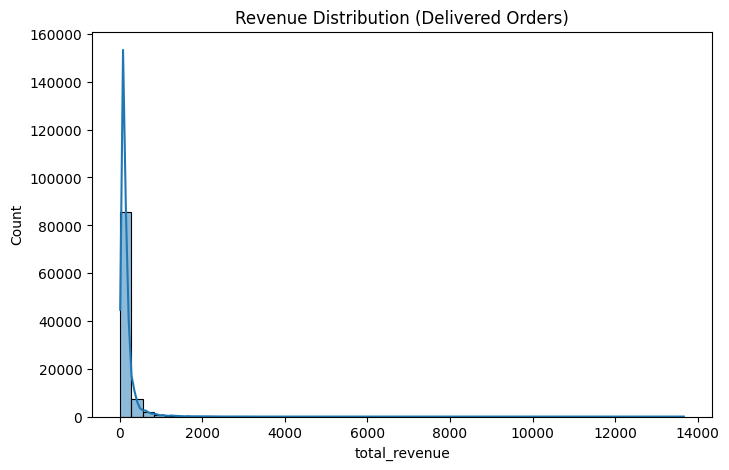

In [135]:
plt.figure(figsize=(8,5))
sns.histplot(df["total_revenue"], bins=50, kde=True)
plt.title("Revenue Distribution (Delivered Orders)")
plt.show()

In [136]:
df["total_revenue"].describe(percentiles=[.5,.75,.90,.95,.99])

count   96478.0000
mean      159.8268
std       218.7942
min         9.5900
50%       105.2800
75%       176.2600
90%       305.9180
95%       446.2320
99%      1052.3899
max     13664.0800
Name: total_revenue, dtype: float64

Revenue distribution is heavily right-skewed.
A small number of high-value orders contribute disproportionately to total revenue.
Median order value is significantly lower than the mean, indicating concentration risk.

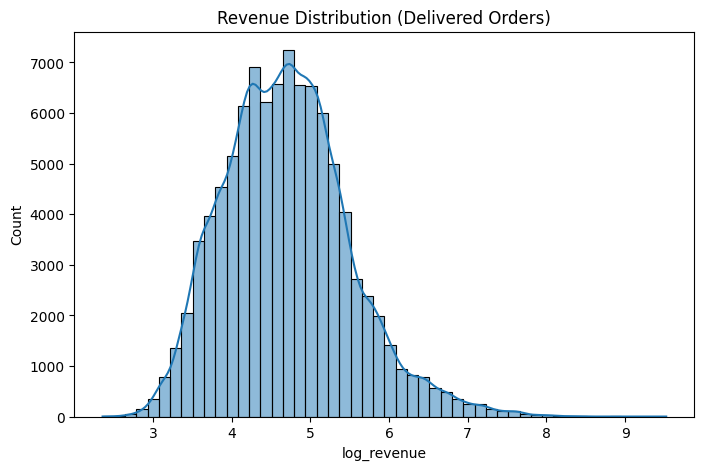

In [138]:
plt.figure(figsize=(8,5))
sns.histplot(df["log_revenue"], bins=50, kde=True)
plt.title("Revenue Distribution (Delivered Orders)")
plt.show()

Log transformation stabilizes variance and reduces skewness.
This transformation is recommended for modeling tasks.

### 2.2. Monthly Average Order Value Trend

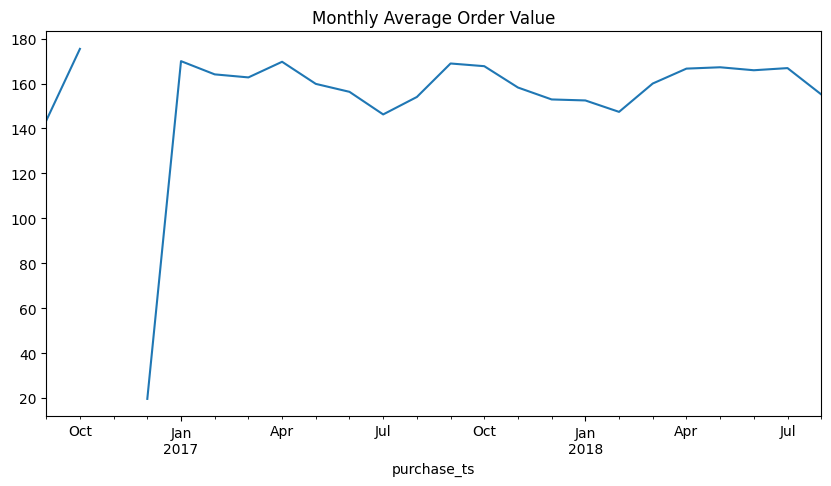

In [141]:
monthly_avgr = (
    df.set_index("purchase_ts")
    .resample("ME")["total_revenue"]
    .mean()
)

monthly_avgr.plot(figsize=(10,5), title="Monthly Average Order Value")
plt.show()

In [142]:
df.resample("ME", on="purchase_ts")["order_id"].count()

purchase_ts
2016-09-30       1
2016-10-31     265
2016-11-30       0
2016-12-31       1
2017-01-31     750
2017-02-28    1653
2017-03-31    2546
2017-04-30    2303
2017-05-31    3546
2017-06-30    3135
2017-07-31    3872
2017-08-31    4193
2017-09-30    4150
2017-10-31    4478
2017-11-30    7289
2017-12-31    5513
2018-01-31    7069
2018-02-28    6555
2018-03-31    7003
2018-04-30    6798
2018-05-31    6749
2018-06-30    6099
2018-07-31    6159
2018-08-31    6351
Freq: ME, Name: order_id, dtype: int64

- Monthly average order value (AOV) remains relatively stable between 150–170.
- No strong upward trend is observed in basket size over time.
- Revenue growth appears to be primarily driven by increasing order volume rather than higher spending per order.
- Early months show volatility due to low order counts.

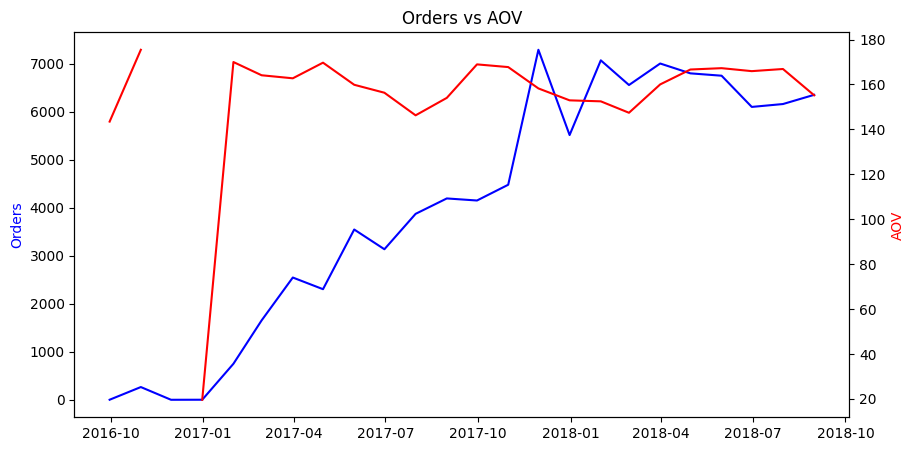

In [144]:
monthly_stats = (
    df.resample("ME", on="purchase_ts")
      .agg(
          revenue=("total_revenue","sum"),
          orders=("order_id","count"),
          aov=("total_revenue","mean")
      )
)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(monthly_stats.index, monthly_stats["orders"], color="blue")
ax1.set_ylabel("Orders", color="blue")

ax2 = ax1.twinx()
ax2.plot(monthly_stats.index, monthly_stats["aov"], color="red")
ax2.set_ylabel("AOV", color="red")

plt.title("Orders vs AOV")
plt.show()

### 2.3. Revenue Concentration (Pareto Analysis)

How much revenue do the top 10% of orders generate?

In [146]:
sorted_rev = df["total_revenue"].sort_values(ascending=False)
cumulative = sorted_rev.cumsum() / sorted_rev.sum()

pareto_10 = cumulative.iloc[int(0.10 * len(df))]
pareto_20 = cumulative.iloc[int(0.20 * len(df))]

pareto_10, pareto_20

(0.3805056251230669, 0.5319247022025853)

* Top 10% of orders contribute approximately 38% of total revenue.
* Top 20% of orders contribute approximately 53% of total revenue.
* This confirms a strong Pareto effect in revenue distribution.

### 2.4. Freight Analysis

In [149]:
df["freight_ratio"] = df["total_freight"] / df["total_revenue"]

df["freight_ratio"].describe(percentiles=[.5,.75,.90,.95])

count   96478.0000
mean        0.2090
std         0.1256
min         0.0000
50%         0.1833
75%         0.2756
90%         0.3836
95%         0.4562
max         0.9555
Name: freight_ratio, dtype: float64

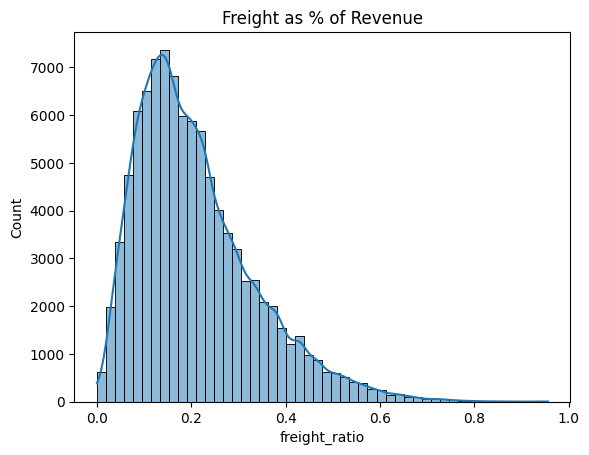

In [150]:
sns.histplot(df["freight_ratio"], bins=50, kde=True)
plt.title("Freight as % of Revenue")
plt.show()

* Freight represents a non-negligible portion of order value.
* High freight ratios may impact customer satisfaction and repeat behavior.

### 2.5. Order Value Segmentation

In [153]:
df["order_value_segment"] = pd.qcut(
    df["total_revenue"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

df["order_value_segment"].value_counts(normalize=True)

order_value_segment
Mid-Low    0.2506
Low        0.2501
High       0.2500
Mid-High   0.2494
Name: proportion, dtype: float64

* Orders are segmented into quartiles based on revenue.

### 2.6. Payment Behavior Analysis

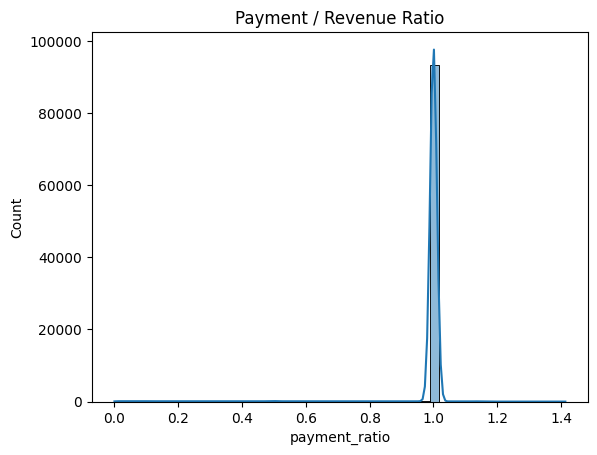

In [156]:
sns.histplot(df["payment_ratio"], bins=50, kde=True)
plt.title("Payment / Revenue Ratio")
plt.show()

In [157]:
df["payment_ratio"].describe()

count   96477.0000
mean        0.9838
std         0.1062
min         0.0000
25%         1.0000
50%         1.0000
75%         1.0000
max         1.4134
Name: payment_ratio, dtype: float64

Payment ratio centers around 1, indicating high reconciliation consistency between payments and recorded revenue.

### 2.7. Discount Intensity

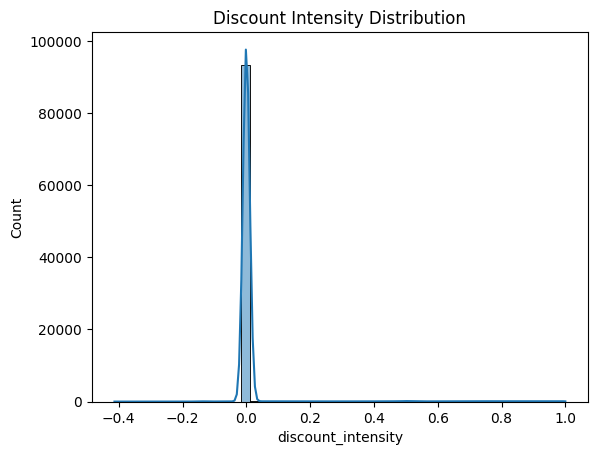

In [160]:
sns.histplot(df["discount_intensity"], bins=50, kde=True)
plt.title("Discount Intensity Distribution")
plt.show()

In [161]:
df["discount_intensity"].describe()

count   96477.0000
mean        0.0162
std         0.1062
min        -0.4134
25%         0.0000
50%         0.0000
75%         0.0000
max         1.0000
Name: discount_intensity, dtype: float64

Generally, aggressive discounts are not observed on the platform. The discount_intensity center is around 0.

### 2.8. Revenue vs Delivery Time

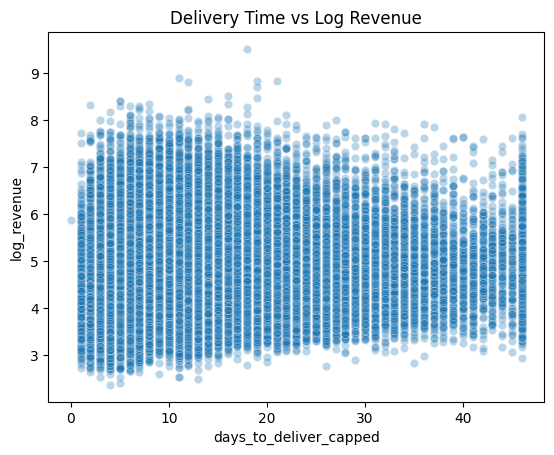

In [164]:
sns.scatterplot(
    x = "days_to_deliver_capped",
    y = "log_revenue",
    data = df,
    alpha=0.3
)

plt.title("Delivery Time vs Log Revenue")
plt.show()

Higher total revenue values ​​are observed in businesses with delivery times shorter than 20 days.

In [166]:
df.groupby("is_late")["total_revenue"].mean()

is_late
0   158.6896
1   172.7096
Name: total_revenue, dtype: float64

### 2.9. Category × Revenue

In [168]:
top_cat = df["main_category_by_item"].value_counts().head(10).index

df[df["main_category_by_item"].isin(top_cat)] \
    .groupby("main_category_by_item")["total_revenue"] \
    .mean() \
    .sort_values(ascending=False)

main_category_by_item
watches_gifts           230.5222
auto                    176.5781
health_beauty           164.1059
computers_accessories   158.7607
sports_leisure          149.2012
toys                    144.7295
furniture_decor         142.0010
bed_bath_table          134.2014
housewares              132.9062
telephony                92.8323
Name: total_revenue, dtype: float64

The highest revenue-generating category is watches gifts.

### 2.10. High Value Order Profile

Let's examine the top 5% of orders:

In [171]:
threshold = df["total_revenue"].quantile(0.95)

high_value = df[df["total_revenue"]>threshold]

high_value.describe().T

,count,mean,min,25%,50%,75%,max,std
purchase_ts,4824,2018-01-03 15:43:34.729477632,2016-10-04 19:25:29,2017-09-14 14:10:48.750000128,2018-01-27 20:32:01,2018-05-11 11:10:18.500000,2018-08-29 14:18:23,NaN
approved_ts,4824,2018-01-04 04:08:25.918532352,2016-10-06 15:44:28,2017-09-14 19:31:38.500000,2018-01-28 10:48:40.500000,2018-05-11 21:17:09.249999872,2018-08-29 14:31:07,NaN
carrier_ts,4824,2018-01-07 21:09:34.028814080,2016-10-11 02:49:22,2017-09-19 18:38:28.500000,2018-02-01 00:48:51,2018-05-14 16:01:45,2018-09-03 12:56:00,NaN
delivered_ts,4824,2018-01-18 04:13:14.358623488,2016-10-14 02:49:22,2017-09-26 22:53:04.249999872,2018-02-16 17:21:03.500000,2018-05-22 17:28:26.750000128,2018-09-12 20:15:38,NaN
days_to_deliver,4824.0000,14.4706,1.0000,8.0000,12.0000,18.0000,195.0000,11.4744
is_late,4824.0000,0.0958,0.0000,0.0000,0.0000,0.0000,1.0000,0.2943
total_price,4824.0000,795.4459,230.0000,499.0000,619.8500,895.0000,13440.0000,546.4276
total_freight,4824.0000,58.8755,0.0000,22.2900,38.8100,70.0050,1794.9600,63.4506
total_revenue,4824.0000,854.3214,446.3000,540.0750,674.8950,947.4425,13664.0800,558.2462
item_count,4824.0000,1.4708,1.0000,1.0000,1.0000,1.0000,20.0000,1.2863


The average number of installments per order in the top 5% is 5.88, with a median of 6. Discount frequency is around 1% on average. The average number of products sold in these orders is 1.46. Generally, more than one product was sold.